In [28]:
from backend.segmentation.segmentation import Segmentor
import torch

model = Segmentor()

model_path = './backend/segmentation/SegFormer_New_Arch_at_0.9400.pth'
            
# Load pretrained weights
checkpoint = torch.load(model_path, map_location='cuda')
model.load_state_dict(checkpoint['model_state_dict'], strict=True)

<All keys matched successfully>

**Axial View**

IoU: 0.7356


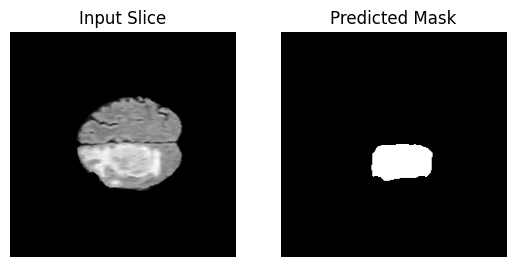

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import cv2
import nibabel as nib

# === Load NIfTI Image ===
nifti_image = nib.load("BraTS19_2013_7_1_flair.nii")
img_3d = nifti_image.get_fdata()
slice_index = 121
slice_data = img_3d[:, :, slice_index]

# === Normalize and Convert to float32 ===
slice_data = ((slice_data - np.min(slice_data)) / (np.max(slice_data) - np.min(slice_data))).astype(np.float32)

# === Device and Model ===
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
model.eval()

# === Prepare Input Tensor ===
input_tensor = torch.from_numpy(slice_data).float()
input_tensor = input_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
input_tensor = input_tensor.repeat(1, 3, 1, 1)         # [1, 3, H, W]
input_tensor = input_tensor.to(device)

# === Inference ===
with torch.no_grad():
    output, _ = model(input_tensor)
    output = torch.sigmoid(output)
    mask = (output > 0.5).float().squeeze().cpu().numpy()

# === Resize Predicted Mask ===
mask = cv2.resize(mask.astype(np.uint8), (slice_data.shape[1], slice_data.shape[0]), interpolation=cv2.INTER_NEAREST)

# === Load Ground Truth NIfTI Mask ===
gt_nifti = nib.load("BraTS19_2013_7_1_seg.nii")
gt_3d = gt_nifti.get_fdata()
gt_mask = gt_3d[:, :, slice_index]
gt_mask = (gt_mask > 0).astype(np.uint8)
gt_mask = cv2.resize(gt_mask, (mask.shape[1], mask.shape[0]), interpolation=cv2.INTER_NEAREST)

# === IoU Calculation ===
intersection = np.logical_and(mask, gt_mask).sum()
union = np.logical_or(mask, gt_mask).sum()
iou = intersection / union if union != 0 else 0
print(f"IoU: {iou:.4f}")

# === Display the Predicted Mask ===
plt.subplot(1, 2, 1)
plt.imshow(slice_data, cmap='gray')
plt.title("Input Slice")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title("Predicted Mask")
plt.axis('off')

plt.show()


**Coronal View**

IoU: 0.7776


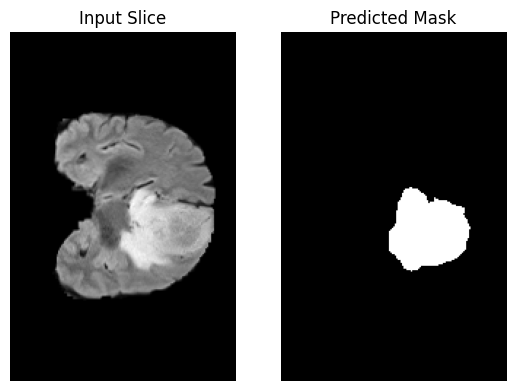

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import cv2
import nibabel as nib

# === Load NIfTI Image ===
nifti_image = nib.load("BraTS19_2013_7_1_flair.nii")
img_3d = nifti_image.get_fdata()
slice_index =  121  # Middle slice

slice_data = img_3d[:, slice_index, :]

# === Normalize and Convert to float32 ===
slice_data = ((slice_data - np.min(slice_data)) / (np.max(slice_data) - np.min(slice_data))).astype(np.float32)

# === Device and Model ===
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
model.eval()

# === Prepare Input Tensor ===
input_tensor = torch.from_numpy(slice_data).float()
input_tensor = input_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
input_tensor = input_tensor.repeat(1, 3, 1, 1)         # [1, 3, H, W]
input_tensor = input_tensor.to(device)

# === Inference ===
with torch.no_grad():
    output, _ = model(input_tensor)
    output = torch.sigmoid(output)
    mask = (output > 0.5).float().squeeze().cpu().numpy()

# === Resize Predicted Mask ===
mask = cv2.resize(mask.astype(np.uint8), (slice_data.shape[1], slice_data.shape[0]), interpolation=cv2.INTER_NEAREST)

# === Load Ground Truth NIfTI Mask ===
gt_nifti = nib.load("BraTS19_2013_7_1_seg.nii")
gt_3d = gt_nifti.get_fdata()
gt_mask = gt_3d[:, slice_index, :]
gt_mask = (gt_mask > 0).astype(np.uint8)
gt_mask = cv2.resize(gt_mask, (mask.shape[1], mask.shape[0]), interpolation=cv2.INTER_NEAREST)

# === IoU Calculation ===
intersection = np.logical_and(mask, gt_mask).sum()
union = np.logical_or(mask, gt_mask).sum()
iou = intersection / union if union != 0 else 0
print(f"IoU: {iou:.4f}")

# === Display the Predicted Mask ===
plt.subplot(1, 2, 1)
plt.imshow(slice_data, cmap='gray')
plt.title("Input Slice")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title("Predicted Mask")
plt.axis('off')

plt.show()


**Sagittal View**

IoU: 0.5960


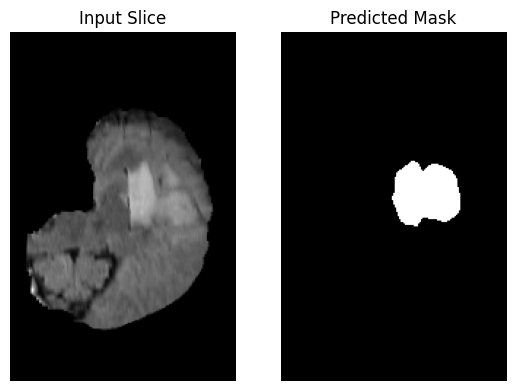

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import cv2
import nibabel as nib

# === Load NIfTI Image ===
nifti_image = nib.load("BraTS19_2013_7_1_flair.nii")
img_3d = nifti_image.get_fdata()
slice_index = 121  # Middle slice
slice_data = img_3d[slice_index, :, :]

# === Normalize and Convert to float32 ===
slice_data = ((slice_data - np.min(slice_data)) / (np.max(slice_data) - np.min(slice_data))).astype(np.float32)

# === Device and Model ===
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
model.eval()

# === Prepare Input Tensor ===
input_tensor = torch.from_numpy(slice_data).float()
input_tensor = input_tensor.unsqueeze(0).unsqueeze(0)  # [1, 1, H, W]
input_tensor = input_tensor.repeat(1, 3, 1, 1)         # [1, 3, H, W]
input_tensor = input_tensor.to(device)

# === Inference ===
with torch.no_grad():
    output, _ = model(input_tensor)
    output = torch.sigmoid(output)
    mask = (output > 0.5).float().squeeze().cpu().numpy()

# === Resize Predicted Mask ===
mask = cv2.resize(mask.astype(np.uint8), (slice_data.shape[1], slice_data.shape[0]), interpolation=cv2.INTER_NEAREST)

# === Load Ground Truth NIfTI Mask ===
gt_nifti = nib.load("BraTS19_2013_7_1_seg.nii")
gt_3d = gt_nifti.get_fdata()
gt_mask = gt_3d[slice_index, :, :]
gt_mask = (gt_mask > 0).astype(np.uint8)
gt_mask = cv2.resize(gt_mask, (mask.shape[1], mask.shape[0]), interpolation=cv2.INTER_NEAREST)

# === IoU Calculation ===
intersection = np.logical_and(mask, gt_mask).sum()
union = np.logical_or(mask, gt_mask).sum()
iou = intersection / union if union != 0 else 0
print(f"IoU: {iou:.4f}")

# === Display the Predicted Mask ===
plt.subplot(1, 2, 1)
plt.imshow(slice_data, cmap='gray')
plt.title("Input Slice")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title("Predicted Mask")
plt.axis('off')

plt.show()
